# Import Library :

In [ ]:
!pip install gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize

from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Load Dataset :

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load CSV
file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Train–Val–Test Split

In [ ]:
# ============================================
# PART 2 — Train–Val–Test Split
# ============================================

# Step 1: Pisahkan test 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 2: Dari sisa 80%, ambil 12.5% sebagai validation (~10% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1445
Validation size: 207
Test size: 414


# Load FastText Embedding (dari Google Drive)

In [ ]:
from gensim.models import KeyedVectors

# Path file .kv hasil convert
save_path = "/content/drive/MyDrive/DistilBERT-7-Mei/fasttext_id.kv"

# Load cepat
w2v = KeyedVectors.load(save_path, mmap='r')

embedding_dim = w2v.vector_size

print("Embedding dim:", embedding_dim)
print("Jumlah kata:", len(w2v))


Embedding dim: 300
Jumlah kata: 2000000


# Tokenizing + Convert Sentence → Vector

In [ ]:
def sentence_to_vector(sentence, ft_dict, dim):
    tokens = word_tokenize(sentence.lower())
    vecs = [ft_dict[t] for t in tokens if t in ft_dict]

    if len(vecs) == 0:
        return np.zeros(dim)

    return np.mean(vecs, axis=0)


# Convert Train/Val/Test → Embedding Matrix

In [ ]:
import nltk
nltk.download('punkt_tab')

X_train_vec = np.array([sentence_to_vector(t, w2v, embedding_dim) for t in X_train])
X_val_vec   = np.array([sentence_to_vector(t, w2v, embedding_dim) for t in X_val])
X_test_vec  = np.array([sentence_to_vector(t, w2v, embedding_dim) for t in X_test])

print("Vector shapes:")
print(X_train_vec.shape, X_val_vec.shape, X_test_vec.shape)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Vector shapes:
(1445, 300) (207, 300) (414, 300)


# Train Final Model dengan Train + Val (FULL TRAINING DATA)

In [ ]:
# Best Params: {'C': 8.966816542050767, 'kernel': 'linear'}

best_C = 8.966816542050767
best_kernel = 'linear'

final_model = SVC(
    C=best_C,
    kernel=best_kernel,
    probability=True,
    random_state=42
)

# Train menggunakan TRAIN + VAL (digabung)
X_fulltrain = np.concatenate([X_train_vec, X_val_vec])
y_fulltrain = pd.concat([y_train, y_val])

final_model.fit(X_fulltrain, y_fulltrain)

# === Evaluation on TEST set ===
from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_pred = final_model.predict(X_test_vec)

f1_macro = f1_score(y_test, y_pred, average="macro")
cls_report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print("\n=== Final SVM Test Evaluation ===")
print("F1-macro:", f1_macro)
print("Accuracy:", cls_report["accuracy"])
print("Classification Report:", cls_report)
print("Confusion Matrix:\n", cm)

# === Inference Time Benchmark (selaras dengan BERT) ===
import time
benchmark_size = min(32, len(X_test_vec))
subset = X_test_vec[:benchmark_size]

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")


=== Final SVM Test Evaluation ===
F1-macro: 0.8343277965919476
Accuracy: 0.8381642512077294
Classification Report: {'0.0': {'precision': 0.8232931726907631, 'recall': 0.8991228070175439, 'f1-score': 0.859538784067086, 'support': 228.0}, '1.0': {'precision': 0.8606060606060606, 'recall': 0.7634408602150538, 'f1-score': 0.8091168091168092, 'support': 186.0}, 'accuracy': 0.8381642512077294, 'macro avg': {'precision': 0.8419496166484118, 'recall': 0.8312818336162988, 'f1-score': 0.8343277965919476, 'support': 414.0}, 'weighted avg': {'precision': 0.8400569339280707, 'recall': 0.8381642512077294, 'f1-score': 0.8368854330024688, 'support': 414.0}}
Confusion Matrix:
 [[205  23]
 [ 44 142]]

🕒 Avg batch inference time: 0.002793240547180176
📊 Throughput: 11456.227796887935 samples/sec



Classification Report:
              precision    recall  f1-score   support

    Bullying     0.8233    0.8991    0.8595       228
Non-bullying     0.8606    0.7634    0.8091       186

    accuracy                         0.8382       414
   macro avg     0.8419    0.8313    0.8343       414
weighted avg     0.8401    0.8382    0.8369       414



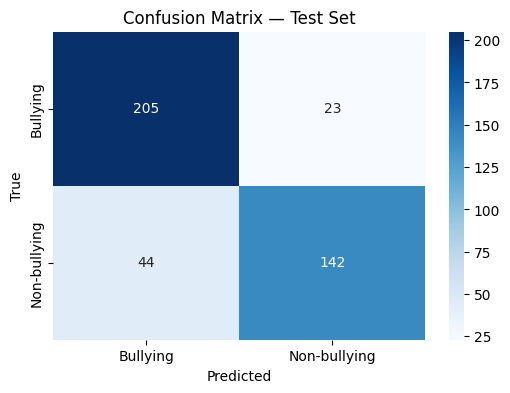

In [ ]:
y_pred = final_model.predict(X_test_vec)
test_f1 = f1_score(y_test, y_pred, average="macro")


label_map = {0: "Bullying", 1: "Non-bullying"}
class_names = [label_map[i] for i in sorted(label_map.keys())]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.show()
